# **LIBRARY**

In [ ]:
!pip install -q sastrawi sentence-transformers bertopic umap-learn hdbscan gensim wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import re
import random

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

import umap
import hdbscan
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel

import matplotlib.pyplot as plt
from wordcloud import WordCloud
from tqdm import tqdm

# **DATA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np


df = pd.read_excel('/content/drive/MyDrive/Data/Komentar.xlsx')
df.head()

,Date,UserName,Comment,Like
0,2026-05-07T13:06:15Z,@ferryirwandi,"hallo warga sipil sekalian, selamat menonton ❤",489
1,2026-05-07T13:08:04Z,@Jall.000,🎉,4
2,2026-05-07T13:08:41Z,@Amadeus_15,Pertama bang🎉,0
3,2026-05-07T13:10:16Z,@SeruanhePi73,Oke bro ferry,0
4,2026-05-07T13:18:44Z,@MAHRUSDARMAWAN-w7n,Sehat sehat bang,0


# **PRE-PROCESSING**

## Default Function

In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import string

custom_phrases = {
    # makroekonomi dasar
    "pertumbuhan ekonomi": "pertumbuhan_ekonomi",
    "resesi ekonomi": "resesi_ekonomi",
    "krisis ekonomi": "krisis_ekonomi",
    "pemulihan ekonomi": "pemulihan_ekonomi",
    "stabilitas ekonomi": "stabilitas_ekonomi",
    "ekonomi indonesia": "ekonomi_indonesia",
    "ekonomi nasional": "ekonomi_nasional",
    "ekonomi rakyat": "ekonomi_rakyat",

    # indikator ekonomi
    "produk domestik bruto": "produk_domestik_bruto",
    "gross domestic product": "gross_domestic_product",
    "daya beli": "daya_beli",
    "nilai tukar": "nilai_tukar",
    "cadangan devisa": "cadangan_devisa",
    "neraca perdagangan": "neraca_perdagangan",
    "defisit anggaran": "defisit_anggaran",
    "surplus perdagangan": "surplus_perdagangan",

    # inflasi
    "inflasi pangan": "inflasi_pangan",
    "inflasi inti": "inflasi_inti",
    "harga pangan": "harga_pangan",
    "harga beras": "harga_beras",
    "harga minyak": "harga_minyak",
    "harga kebutuhan": "harga_kebutuhan",
    "bahan pokok": "bahan_pokok",
    "kebutuhan pokok": "kebutuhan_pokok",
    "biaya hidup": "biaya_hidup",

    # tenaga kerja
    "lapangan pekerjaan": "lapangan_pekerjaan",
    "tenaga kerja": "tenaga_kerja",
    "pengangguran terbuka": "pengangguran_terbuka",
    "upah minimum": "upah_minimum",
    "gaji minimum": "gaji_minimum",

    # finansial
    "suku bunga": "suku_bunga",
    "bunga kredit": "bunga_kredit",
    "bunga bank": "bunga_bank",
    "kartu kredit": "kartu_kredit",
    "pinjaman online": "pinjaman_online",
    "utang luar negeri": "utang_luar_negeri",
    "utang negara": "utang_negara",

    # mata uang
    "bank indonesia": "bank_indonesia",
    "nilai rupiah": "nilai_rupiah",
    "mata uang": "mata_uang",
    "uang rakyat": "uang_rakyat",
    "uang negara": "uang_negara",
    "nilai tukar":"nilai_tukar",

    # Kata-kata
    "omong kosong":"omong_kosong",
    "merah putih":"merah_putih",
    "ferry irwandi":"ferry_irwandi",
    "raymond chin":"raymond_chin",
}

custom_slang = {
    # EKSPRESI & EMOSI
    "woww":"kaget","bjir":"kaget","bjirr":"kaget",
    "hiks":"sedih","nangiz":"sedih","mewek":"sedih",
    "wkwk":"lucu","wkwkwk":"lucu","wkwkwkwk":"lucu",
    "wkwkwkw":"lucu","wkwkwkwkk":"lucu","hshshs":
    "lucu","ngakak":"lucu","tawa":"lucu","zonk":"jelek",
    "boring":"bosan","sebel":"kesal","nyebelin":"kesal",
    "ngeselin":"kesal",

    # UMUM LAIN
    "temen":"teman","dateng":"datang","gede":"besar","mayan":"lumayan","spending":"pengeluaran",
    "favorit":"suka","like":"suka","love":"suka","sukaa":"suka","duit":"uang","dolar":"dollar",
    "umur":"usia","indo":"indonesia","indon":"indonesia","mentri":"menteri","government":"pemerintah",
    "project":"proyek","projek":"proyek","waktu":"durasi", "lama" : "durasi", "cepat":"durasi",
    "culture":"budaya","experience":"pengalaman","anggaran":"apbn","projek":"proyek","goverment":"pemerintah",
    "antusiasme":"antusias","excited":"antusias","import":"impor","gampang":"mudah","betul":"benar",
    "relate":"cocok","tepat":"cocok","pas":"cocok","rakyatnya":"rakyat","export":"ekspor","warga":"rakyat",
    "wowo":"prabowo","negri":"negeri","cerdas":"pintar","ekonominya":"ekonomi","aamiin":"amin",
    "ngibul":"bohong","effect":"efek","uangnya":"uang","growth":"pertumbuhan","makasih":"terimakasih",
    "bacot":"berisik","dongo":"bodoh","dungu":"bodoh","hasilnya":"hasil","stop":"berhenti","fery":"ferry",
    "spendingnya":"pengeluaran","datanya":"data","omonomon":"omon-omon","nyungsep":"jatuh","demand":"permintaan",
    "duitnya":"uang","penjelasannya":"penjelasan","real":"fakta","faktanya":"fakta","naek":"naik","gilaan":"gila",
    "nunggu":"tunggu","expor":"ekspor","efeknya":"efek","sebenernya":"fakta","kenyataannya":"fakta","nilainya":"nilai",
    "money":"uang","negaranya":"negara","kerjanya":"kerja","budget":"anggaran","spend":"pengeluaran","abis":"habis",
    "elite":"elit","presidennya":"presiden","seneng":"senang","full":"penuh","harganya":"harga","omon":"omong_kosong",
}

# Custom Stopword
custom_stopwords = {
    "nya", "nih", "sih", "deh", "dong","kalau","jadi","apa","kenapa","bagaimana","kapan",
    "tuh", "ya", "yg", "aja", "kok","mau","buat","terus","semua","cuma","udah","sangat",
    "lah", "kan", "mah", "kayak","mana","tetap","punya","biar","bang","pak","tau","banget",
    "gue", "gua", "aku", "saya","orang","masyarakat","durasi","purbaya","indonesia","banyak",
    "kamu", "dia", "mereka","sama","lebih","bukan","sekarang","makin","jangan","pernah","wkwk",
    "selalu","baru","malah","dulu","bawah","bikin","luar","salah","semoga","tinggal","tersebut",
    "masuk","asing","maju","jelas","satu","menjadi","paling","bilang","sendiri","memang",
    "langsung","padahal","emang","gimana","paham","coba","atas","tiap","seluruh","usah",
    "melemah","bener","cara","ribu","bapak","semakin","ngomong","cocok","doang","bakal",
    "karna","href","berarti","liat","terjadi","selama","terlalu","artinya","tahu","namanya",
    "perlu", "harusnya","ternyata","katanya","bahkan","hari","siapa","jauh","lalu","untung",
    "biasa","lihat","gitu","sedang","butuh","sampe","mulai","kata","pake","jalan","gini",
    "kali","sebenarnya","awal","sekali","ikut","kebanyakan","kenaikan","sesuai","intinya",
    "persen","beliau","cukup","akhirnya","pakai","kurang","justru","bahas","diri","suatu",
    "tambah","termasuk","terima","mati","membuat","soros","terlihat","diatas","sedikit",
    "kalian","gila","makanya","melihat","alias","cuman","lewat","bung","terutama","masa",
    "dasar","skrg","sering","lainnya","ngerti","dibawah","sebelumnya","kayaknya","apapun",
    "adanya","melalui","dapet","kemarin","biasanya","sejak","mbak","beberapa","tetep","trus",
    "gara","kedepan","kasian","kira","segala","hinggga","sini","kelihatan","mending","berapa",
    "walaupun","mulu","segera","sana","bila","sebagian","keliatan","ngak","soalnya","sekalian",
    "sepertinya","berikutnya","abang","bnyk","tertentu","disini","terkait","kaga","entah","ngapain",
    "entah","pengen","tiba","ntar","krna","kedepannya","inilah","kagak","berdasarkan","masing",
    "tergantung","sekian","berasa","msih","slalu","sepanjang","hahaha","segitu","meski","wkwkwk",
    "yang","tidak","kalau","kalo","ngga",

    # hapus noise youtube
    "subscribe", "like", "komen",
    "comment", "share", "youtube",
    "channel",
}

factory = StopWordRemoverFactory()
sastrawi_stopwords = set(factory.get_stop_words())

all_stopwords = (
    sastrawi_stopwords
    .union(custom_stopwords)
)

# Stopword yang jangan dihapus
protected_words = set(custom_slang.values())

# Cleaning
def clean_text(text):
    if pd.isna(text):
        return ""
    # lowercase
    text = text.lower()
    # hapus url
    text = re.sub(
        r'http\S+|www\S+|https\S+',
        '',
        text
    )
    # hapus html
    text = re.sub(r'<.*?>', '', text)
    # hapus mention & hashtag
    text = re.sub(r'@\w+|#\w+', '', text)
    # hapus angka
    text = re.sub(r'\d+', '', text)
    # hapus emoji & non-ascii
    text = text.encode(
        'ascii',
        'ignore'
    ).decode('ascii')
    # hapus punctuation
    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )
    # rapikan whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Default Function Tokenisasi
def tokenize_text(text):

    return text.split()

# Default Function Normalisasi
def normalize_phrases(tokens):

    text = " ".join(tokens)

    for phrase, replacement in custom_phrases.items():

        text = re.sub(
            rf'\b{re.escape(phrase)}\b',
            replacement,
            text
        )

    return text.split()

def normalize_tokens(tokens):

    normalized_tokens = []

    for token in tokens:

        normalized_token = custom_slang.get(
            token,
            token
        )

        normalized_tokens.append(
            normalized_token
        )

    return normalized_tokens

# Default Function Remove Stopwords
def remove_stopwords(tokens):

    filtered_tokens = []

    for token in tokens:

        if (
            token not in all_stopwords
            or token in protected_words
        ):
            filtered_tokens.append(token)

    return filtered_tokens

# Remove Shortwords
def remove_short_words(tokens):

    return [
        token
        for token in tokens
        if len(token) > 3
    ]

def preprocess_text(text):
    # 1. cleaning
    text = clean_text(text)
    # 2. tokenisasi
    tokens = tokenize_text(text)
    # 3. phrase normalization
    tokens = normalize_phrases(tokens)
    # 4. slang normalization
    tokens = normalize_tokens(tokens)
    # 5. stopword removal
    tokens = remove_stopwords(tokens)
    # 6. remove short words
    tokens = remove_short_words(tokens)
    # join kembali
    return " ".join(tokens)

## Eksekusi Pre-Processing

In [ ]:
df['clean_comment'] = df['Comment'].apply(preprocess_text)
df = df[df['clean_comment'].str.strip() != ""]
df = df.drop_duplicates(subset='clean_comment')
df = df.reset_index(drop=True)
df[['Comment', 'clean_comment']].head(10)

,Comment,clean_comment
0,"hallo warga sipil sekalian, selamat menonton ❤",hallo rakyat sipil selamat menonton
1,Pertama bang🎉,pertama
2,Oke bro ferry,ferry
3,Sehat sehat bang,sehat sehat
4,Bang... Penasaran... Pernah gakk riset perikon...,penasaran gakk riset perikonomian desa desa da...
5,kita semua terkecoh warga XD,terkecoh rakyat
6,Faktor utamanya emang harus perkuat ekspor sam...,faktor utamanya perkuat ekspor investasi ketah...
7,"Pertanyaan, berarti pertumbuhan ekonomi tuh se...",pertanyaan pertumbuhan_ekonomi dana terserap w...
8,Efisiensi katanya wkwkwk tpi government spendi...,efisiensi lucu pemerintah pengeluaran naik amp...
9,"jadi mau nya yg mana yg tinggi ?, ekspor? tapi...",tinggi ekspor koarquot rupiah


# **EKSPLORASI**

In [ ]:
from collections import Counter
import pandas as pd

tokens = []

for text in df['clean_comment']:
    tokens.extend(text.split())

word_freq = Counter(tokens)


freq_df = pd.DataFrame(
    word_freq.items(),
    columns=['word', 'frequency']
)

freq_df = freq_df.sort_values(
    by='frequency',
    ascending=False
).reset_index(drop=True)

# tampilkan
freq_df.head(100)

,word,frequency
0,ekonomi,702
1,pemerintah,648
2,indonesia,585
3,negara,553
4,rupiah,477
...,...,...
95,bohong,53
96,proyek,52
97,bayar,51
98,modal,50


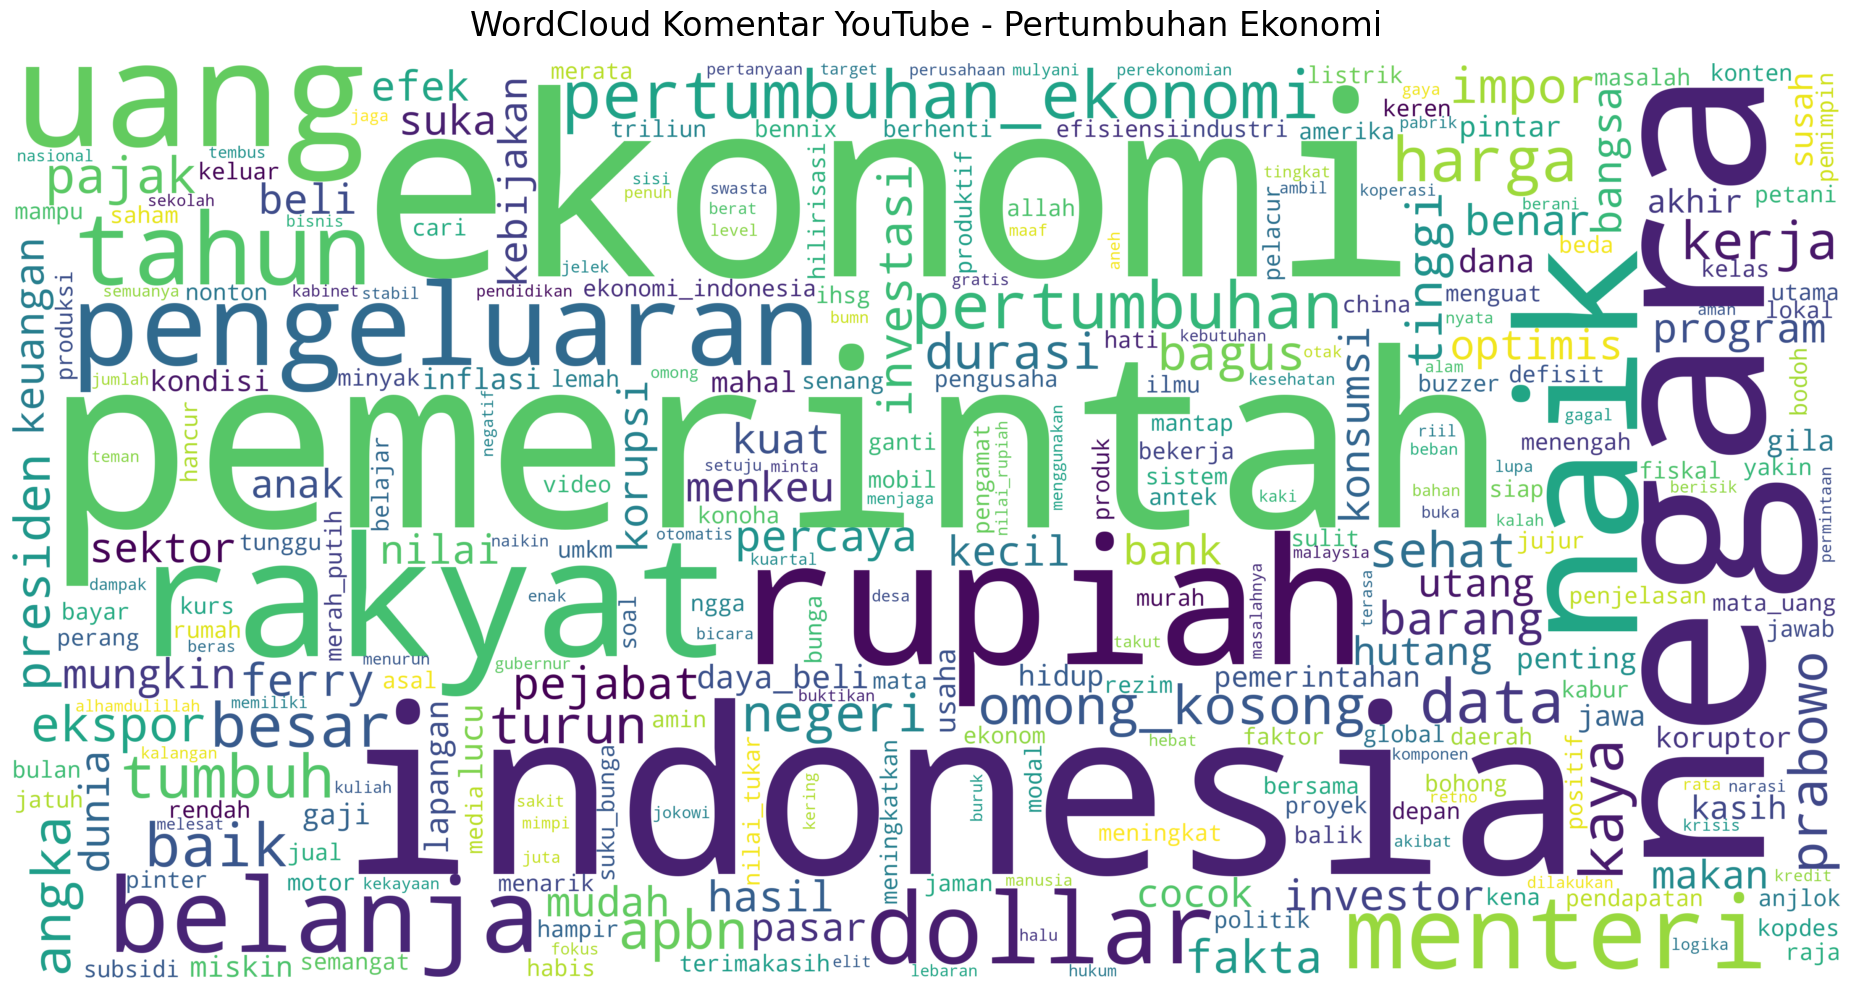

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud_dict = dict(
    zip(freq_df['word'], freq_df['frequency'])
)

wc = WordCloud(
    width=1600,
    height=800,

    background_color='white',
    max_words=300,
    max_font_size=220,
    min_font_size=10,

    random_state=42,
    collocations=False,
    scale=3,
    margin=2,
    prefer_horizontal=0.9

).generate_from_frequencies(wordcloud_dict)

# Plot
plt.figure(figsize=(20, 10))

plt.imshow(
    wc,
    interpolation='bilinear'
)

plt.axis('off')

plt.title(
    'WordCloud Komentar YouTube - Pertumbuhan Ekonomi',
    fontsize=24,
    pad=20
)

plt.tight_layout()

plt.show()

# **TEXT EMBEDDING**

In [ ]:
embedding_model = SentenceTransformer("indobenchmark/indobert-base-p1")
docs = df["clean_comment"].tolist()
embeddings = embedding_model.encode(docs, show_progress_bar=True)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Batches:   0%|          | 0/148 [00:00<?, ?it/s]

# **DEF FUNCTION**

In [ ]:
def compute_coherence(topic_model, docs):
    topics = topic_model.get_topics()

    topic_words = []
    for topic_id in topics:
        if topic_id == -1:
            continue
        words = [w for w, _ in topics[topic_id][:10]]
        if len(words) > 0:
            topic_words.append(words)

    if len(topic_words) < 2:
        return 0

    tokenized_docs = [doc.split() for doc in docs]
    dictionary = Dictionary(tokenized_docs)

    try:
        cm = CoherenceModel(
            topics=topic_words,
            texts=tokenized_docs,
            dictionary=dictionary,
            coherence='c_v'
        )
        return cm.get_coherence()
    except:
        return 0


def compute_diversity(topic_model):
    topics = topic_model.get_topics()

    topic_sets = []
    for topic_id in topics:
        if topic_id == -1:
            continue
        words = [w for w, _ in topics[topic_id][:10]]
        if len(words) > 0:
            topic_sets.append(set(words))

    if len(topic_sets) < 2:
        return 0

    n = len(topic_sets)

    jaccard_sum = 0
    count = 0

    for i in range(n):
        for j in range(i+1, n):
            union = topic_sets[i].union(topic_sets[j])
            if len(union) == 0:
                continue
            inter = topic_sets[i].intersection(topic_sets[j])
            jaccard_sum += len(inter) / len(union)
            count += 1

    if count == 0:
        return 0

    rdj = (2 / (n * (n - 1))) * jaccard_sum
    return 1 - rdj

# **SKENARIO I : TANPA UMAP**

In [ ]:
import hdbscan
from bertopic import BERTopic

print("\n=== SKENARIO 1: TANPA UMAP ===")
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=5,
    metric='euclidean',
    prediction_data=True
)

topic_model_1 = BERTopic(
    umap_model=None,
    hdbscan_model=hdbscan_model,
    verbose=True
)

topics_1, _ = topic_model_1.fit_transform(docs, embeddings)
coherence_1 = compute_coherence(topic_model_1, docs)
diversity_1 = compute_diversity(topic_model_1)

print("\nHasil Skenario 1:")
print("Jumlah topic:", len(set(topics_1)))
print("Coherence:", coherence_1)
print("Diversity:", diversity_1)

2026-05-13 05:44:49,244 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



=== SKENARIO 1: TANPA UMAP ===


2026-05-13 05:45:35,583 - BERTopic - Dimensionality - Completed ✓
2026-05-13 05:45:35,586 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-13 05:45:35,832 - BERTopic - Cluster - Completed ✓
2026-05-13 05:45:35,843 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-13 05:45:35,998 - BERTopic - Representation - Completed ✓



Hasil Skenario 1:
Jumlah topic: 44
Coherence: 0.4320016478569702
Diversity: 0.9900596985700305


In [ ]:
print(topic_model_1.get_topic_info())

    Topic  Count                                               Name  \
0      -1   2202                   -1_ekonomi_indonesia_rakyat_naik   
1       0    202                0_prabowo_menteri_koruptor_presiden   
2       1    158                  1_omonomon_korupsi_pejabat_rakyat   
3       2    150                        2_sehat_amin_allah_semangat   
4       3    141                          3_best_dopping_sales_pura   
5       4    136              4_ekonomi_negara_pemerintah_indonesia   
6       5    120               5_rakyat_pemerintah_negara_indonesia   
7       6    105                     6_rupiah_menguat_dollar_anjlok   
8       7    103  7_pengeluaran_pemerintah_pertumbuhanekonomi_tahun   
9       8     92             8_wkwkwkkwkw_omonnnn_njirrr_ngimpiiiii   
10      9     71                         9_keren_mantap_bagus_cocok   
11     10     70                        10_quot_ciao_bella_omonquot   
12     11     66                     11_ekspor_rupiah_saham_tambang   
13    

# **SKENARIO II : DENGAN UMAP**

In [ ]:
import umap

print("\n=== SKENARIO 2: DENGAN UMAP ===")

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=15,
    metric='cosine',
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=5,
    metric='euclidean',
    prediction_data=True
)

topic_model_2 = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
)

topics_2, _ = topic_model_2.fit_transform(docs, embeddings)
coherence_2 = compute_coherence(topic_model_2, docs)
diversity_2 = compute_diversity(topic_model_2)

print("\nHasil Skenario 2:")
print("Jumlah topic:", len(set(topics_2)))
print("Coherence:", coherence_2)
print("Diversity:", diversity_2)

2026-05-13 05:46:32,714 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



=== SKENARIO 2: DENGAN UMAP ===


2026-05-13 05:46:50,253 - BERTopic - Dimensionality - Completed ✓
2026-05-13 05:46:50,255 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-13 05:46:50,768 - BERTopic - Cluster - Completed ✓
2026-05-13 05:46:50,775 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-13 05:46:50,936 - BERTopic - Representation - Completed ✓



Hasil Skenario 2:
Jumlah topic: 6
Coherence: 0.541189546606712
Diversity: 0.9836257309941521


In [ ]:
reduced_embeddings = topic_model_2.umap_model.embedding_
print("Dimensi setelah UMAP:", reduced_embeddings.shape)

Dimensi setelah UMAP: (4721, 15)


# **SKENARIO III : DENGAN UMAP DAN HYPERPARAMETER TUNING**

## Objective Function

In [ ]:
def objective(params):
    n_neighbors, min_cluster_size = params

    try:
        umap_model = umap.UMAP(
            n_neighbors=int(n_neighbors),
            n_components=5,
            metric='cosine',
            random_state=42
        )

        hdbscan_model = hdbscan.HDBSCAN(
            min_cluster_size=int(min_cluster_size),
            min_samples=5,
            metric='euclidean',
            prediction_data=True
        )

        topic_model = BERTopic(
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            calculate_probabilities=False,
            verbose=False
        )

        topics, _ = topic_model.fit_transform(docs, embeddings)
        unique_topics = set(topics)
        num_valid_topics = len([t for t in unique_topics if t != -1])

        if num_valid_topics < 2:
            return 0, 0, -1, None  # penalti

        coherence = compute_coherence(topic_model, docs)
        diversity = compute_diversity(topic_model)

        score = coherence + diversity

        return coherence, diversity, score, topic_model

    except Exception as e:
        print("Error:", e)
        return 0, 0, -1, None

## ABC Algorithm

In [ ]:
import numpy as np
import random

def abc_optimization(
    objective,
    num_bees=10,
    max_iter=10,
    limit=5,
):
    dim = 2


    def random_solution():
        return [
            random.randint(10, 30),  # param 1
            random.randint(10, 50)   # param 2
        ]

    # Inisialisasi acak
    solutions = [random_solution() for _ in range(num_bees)]
    fitness = []
    trials = [0] * num_bees

    best_score = -np.inf
    best_params = None
    best_model = None
    best_coherence = 0
    best_diversity = 0

    # evaluasi awal
    print("\n=== Initial Population ===")
    for i in range(num_bees):
        coh, div, score, model = objective(solutions[i])
        fitness.append(score)

        print(f"Init {solutions[i]} → Coh: {coh:.4f} | Div: {div:.4f} | Score: {score:.4f}")

        if model is not None and score > best_score:
            best_score = score
            best_params = solutions[i]
            best_model = model
            best_coherence = coh
            best_diversity = div

   # Iterasi utama
    for iteration in range(max_iter):
        print(f"\n===== Iteration {iteration+1} =====")

        # Employee Bee
        for i in range(num_bees):
            k = random.choice([j for j in range(num_bees) if j != i])
            phi = random.uniform(-1, 1)

            new_solution = solutions[i].copy()
            d = random.randint(0, dim-1)
            new_solution[d] = int(
                new_solution[d] + phi * (new_solution[d] - solutions[k][d])
            )

            new_solution[0] = int(np.clip(new_solution[0], 10, 30))
            new_solution[1] = int(np.clip(new_solution[1], 10, 50))

            coh, div, score, model = objective(new_solution)

            print(f"[Employed] {new_solution} → Coh: {coh:.4f} | Div: {div:.4f} | Score: {score:.4f}")

            if score > fitness[i]:
                solutions[i] = new_solution
                fitness[i] = score
                trials[i] = 0

                if model is not None and score > best_score:
                    best_score = score
                    best_params = new_solution
                    best_model = model
                    best_coherence = coh
                    best_diversity = div
            else:
                trials[i] += 1

        # Onlooker Bee
        prob = np.array(fitness)
        prob = prob / prob.sum() if prob.sum() != 0 else np.ones(num_bees)/num_bees

        for _ in range(num_bees):
            i = np.random.choice(range(num_bees), p=prob)

            k = random.choice([j for j in range(num_bees) if j != i])
            phi = random.uniform(-1, 1)

            new_solution = solutions[i].copy()
            d = random.randint(0, dim-1)

            new_solution[d] = int(
                new_solution[d] + phi * (new_solution[d] - solutions[k][d])
            )

            new_solution[0] = int(np.clip(new_solution[0], 10, 30))
            new_solution[1] = int(np.clip(new_solution[1], 10, 50))

            coh, div, score, model = objective(new_solution)

            print(f"[Onlooker] {new_solution} → Coh: {coh:.4f} | Div: {div:.4f} | Score: {score:.4f}")

            if score > fitness[i]:
                solutions[i] = new_solution
                fitness[i] = score
                trials[i] = 0

                if model is not None and score > best_score:
                    best_score = score
                    best_params = new_solution
                    best_model = model
                    best_coherence = coh
                    best_diversity = div
            else:
                trials[i] += 1

        # Scout Bee
        for i in range(num_bees):
            if trials[i] >= limit:
                print(f"[Scout] Reinitializing {solutions[i]}")

                solutions[i] = random_solution()
                coh, div, score, model = objective(solutions[i])
                fitness[i] = score
                trials[i] = 0

                print(f"[Scout New] {solutions[i]} → Coh: {coh:.4f} | Div: {div:.4f} | Score: {score:.4f}")

                if model is not None and score > best_score:
                    best_score = score
                    best_params = solutions[i]
                    best_model = model
                    best_coherence = coh
                    best_diversity = div

    return best_params, best_coherence, best_diversity, best_score, best_model

In [ ]:
best_params, best_coh, best_div, best_score, best_model = abc_optimization(
    objective,
    num_bees=10,
    max_iter=10,
    limit=5
)


=== Initial Population ===
Init [26, 48] → Coh: 0.5096 | Div: 0.9474 | Score: 1.4569
Init [14, 25] → Coh: 0.5278 | Div: 0.9727 | Score: 1.5006
Init [17, 13] → Coh: 0.4210 | Div: 0.9948 | Score: 1.4158
Init [16, 18] → Coh: 0.4218 | Div: 0.9906 | Score: 1.4125
Init [27, 42] → Coh: 0.4755 | Div: 0.9454 | Score: 1.4209
Init [22, 50] → Coh: 0.4793 | Div: 0.9454 | Score: 1.4247
Init [15, 20] → Coh: 0.5143 | Div: 0.9727 | Score: 1.4870
Init [14, 29] → Coh: 0.5278 | Div: 0.9727 | Score: 1.5006
Init [26, 28] → Coh: 0.5153 | Div: 0.9630 | Score: 1.4783
Init [12, 38] → Coh: 0.5028 | Div: 0.9542 | Score: 1.4570

===== Iteration 1 =====
[Employed] [25, 48] → Coh: 0.4755 | Div: 0.9454 | Score: 1.4209
[Employed] [14, 23] → Coh: 0.5278 | Div: 0.9727 | Score: 1.5006
[Employed] [14, 13] → Coh: 0.5420 | Div: 0.9630 | Score: 1.5050
[Employed] [23, 18] → Coh: 0.4479 | Div: 0.9899 | Score: 1.4379
[Employed] [27, 42] → Coh: 0.4755 | Div: 0.9454 | Score: 1.4209
[Employed] [22, 50] → Coh: 0.4793 | Div: 0.9454

In [ ]:
print("\n=== BEST RESULT ===")
print("Best Params     :", best_params)
print("Best Coherence  :", best_coh)
print("Best Diversity  :", best_div)
print("Best Score      :", best_score)


=== BEST RESULT ===
Best Params     : [23, 30]
Best Coherence  : 0.5446632137996346
Best Diversity  : 0.9727095516569201
Best Score      : 1.5173727654565545


## Grid Search

In [ ]:
import itertools
import numpy as np

def grid_search_optimization(objective):

    n_neighbors_range = range(10, 31) # Dilebihkan 1 karena batas akhir itu tidak masuk dalam rentang pencarian
    min_cluster_size_range = range(10, 51)

    best_score = -np.inf
    best_params = None
    best_model = None
    best_coherence = 0
    best_diversity = 0

    all_combinations = list(itertools.product(
        n_neighbors_range,
        min_cluster_size_range
    ))

    print(f"Total combinations: {len(all_combinations)}")

    for params in all_combinations:

        coh, div, score, model = objective(params)

        print(
            f"{params} → "
            f"Coh: {coh:.4f} | "
            f"Div: {div:.4f} | "
            f"Score: {score:.4f}"
        )

        if model is not None and score > best_score:
            best_score = score
            best_params = params
            best_model = model
            best_coherence = coh
            best_diversity = div

    return (
        best_params,
        best_coherence,
        best_diversity,
        best_score,
        best_model
    )

In [ ]:
best_params_gs, best_coh_gs, best_div_gs, best_score_gs, best_model_gs = grid_search_optimization(objective)

Total combinations: 861
(10, 10) → Coh: 0.4011 | Div: 0.9962 | Score: 1.3973
(10, 11) → Coh: 0.4079 | Div: 0.9959 | Score: 1.4038
(10, 12) → Coh: 0.4117 | Div: 0.9950 | Score: 1.4066
(10, 13) → Coh: 0.5123 | Div: 0.9845 | Score: 1.4969
(10, 14) → Coh: 0.5123 | Div: 0.9845 | Score: 1.4969
(10, 15) → Coh: 0.5123 | Div: 0.9845 | Score: 1.4969
(10, 16) → Coh: 0.5123 | Div: 0.9845 | Score: 1.4969
(10, 17) → Coh: 0.4777 | Div: 0.9819 | Score: 1.4596
(10, 18) → Coh: 0.4872 | Div: 0.9856 | Score: 1.4728
(10, 19) → Coh: 0.4855 | Div: 0.9784 | Score: 1.4638
(10, 20) → Coh: 0.5028 | Div: 0.9542 | Score: 1.4570
(10, 21) → Coh: 0.5028 | Div: 0.9542 | Score: 1.4570
(10, 22) → Coh: 0.5028 | Div: 0.9542 | Score: 1.4570
(10, 23) → Coh: 0.5028 | Div: 0.9542 | Score: 1.4570
(10, 24) → Coh: 0.5028 | Div: 0.9542 | Score: 1.4570
(10, 25) → Coh: 0.5028 | Div: 0.9542 | Score: 1.4570
(10, 26) → Coh: 0.5028 | Div: 0.9542 | Score: 1.4570
(10, 27) → Coh: 0.5028 | Div: 0.9542 | Score: 1.4570
(10, 28) → Coh: 0.5028

In [ ]:
print("Best Parameters:", best_params_gs)
print("Best Coherence:", best_coh_gs)
print("Best Diversity:", best_div_gs)
print("Best Score:", best_score_gs)

Best Parameters: (24, 15)
Best Coherence: 0.5655452712875195
Best Diversity: 0.9730994152046784
Best Score: 1.5386446864921979


# **TOPIC MODELLING 1**

In [ ]:
from bertopic.representation import MaximalMarginalRelevance

mmr = MaximalMarginalRelevance(diversity=0.3)

topic_model = BERTopic(
    umap_model=best_model_gs.umap_model,
    hdbscan_model=best_model_gs.hdbscan_model,
    vectorizer_model=best_model_gs.vectorizer_model,
    representation_model=mmr,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

2026-05-13 12:22:04,838 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-13 12:22:20,080 - BERTopic - Dimensionality - Completed ✓
2026-05-13 12:22:20,081 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-13 12:22:20,322 - BERTopic - Cluster - Completed ✓
2026-05-13 12:22:20,328 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-13 12:22:20,453 - BERTopic - Representation - Completed ✓


In [ ]:
print("Shape embeddings sebelum UMAP:")
print(embeddings.shape)
reduced_embeddings = best_model_gs.umap_model.transform(embeddings)

print("\nShape embeddings setelah UMAP:")
print(reduced_embeddings.shape)

Shape embeddings sebelum UMAP:
(4721, 768)

Shape embeddings setelah UMAP:
(4721, 5)


## Summary

In [ ]:
topic_info = topic_model.get_topic_info()
print(topic_info)

   Topic  Count                                   Name  \
0     -1    186            -1_koma_naik_enam_indonesia   
1      0   4378  0_ekonomi_pemerintah_indonesia_negara   
2      1     63        1_quot_pemerintah_retno_bersama   
3      2     46   2_omongkosong_buktikan_teman_menteri   
4      3     32    3_omongkosong_buktikan_omong_gempar   
5      4     16                4_motor_kaos_kaki_mobil   

                                      Representation  \
0  [koma, naik, enam, indonesia, angka, data, bel...   
1  [ekonomi, pemerintah, indonesia, negara, rupia...   
2  [quot, pemerintah, retno, bersama, ribuquot, s...   
3  [omongkosong, buktikan, teman, menteri, majika...   
4  [omongkosong, buktikan, omong, gempar, tangan,...   
5  [motor, kaos, kaki, mobil, listrik, tablet, se...   

                                 Representative_Docs  
0  [ferry nyebutin angka desimal angka dibelakang...  
1  [indonesia kaya raya pejabatnya rakyat sembuny...  
2  [awalnya optimis quotkata prabow

## Proporsi Topik

In [ ]:
topic_counts = topic_info[["Topic","Count"]]
topic_counts["Percentage"] = topic_counts["Count"] / topic_counts["Count"].sum()
print(topic_counts)

   Topic  Count  Percentage
0     -1    186    0.039398
1      0   4378    0.927346
2      1     63    0.013345
3      2     46    0.009744
4      3     32    0.006778
5      4     16    0.003389


## Keyword per Topik (TF-IDF)

In [ ]:
for topic_id in topic_model.get_topics():
    if topic_id == -1:
        continue
    print(f"\nTopic {topic_id}:")
    print(topic_model.get_topic(topic_id))


Topic 0:
[('ekonomi', np.float64(0.0363304535258116)), ('pemerintah', np.float64(0.034511899887459105)), ('indonesia', np.float64(0.03209999538183722)), ('negara', np.float64(0.031728898649347304)), ('rupiah', np.float64(0.028174871438533408)), ('rakyat', np.float64(0.027095296609209406)), ('naik', np.float64(0.026430279541175175)), ('uang', np.float64(0.023486426068621922)), ('pengeluaran', np.float64(0.018718465762668782)), ('belanja', np.float64(0.017624899528770267)), ('dollar', np.float64(0.01700604512746915)), ('menteri', np.float64(0.016824400936652224)), ('tahun', np.float64(0.016809466292676406)), ('pertumbuhanekonomi', np.float64(0.016642975850085534)), ('pertumbuhan', np.float64(0.01620399456166977)), ('harga', np.float64(0.015017618972379724)), ('besar', np.float64(0.014136846862840464)), ('baik', np.float64(0.01356120545847152)), ('data', np.float64(0.013469734351827894)), ('tumbuh', np.float64(0.013394127354637532)), ('apbn', np.float64(0.01332873343001095)), ('kaya', np

## Outlier

In [ ]:
outlier_pct = (topic_info.loc[topic_info["Topic"] == -1, "Count"].values[0]) / len(docs)
print("Outlier %:", outlier_pct)

Outlier %: 0.03939843253547977


# **VISUALISASI**

## UMAP Plot

In [ ]:
from umap import UMAP
reduced_embeddings = UMAP(n_neighbors=24, n_components=5, min_dist=0.0, metric='cosine').fit_transform(embeddings)
topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings)

## Topic Distribution

In [ ]:
topic_model.visualize_barchart()

## **Wordcloud Topic**

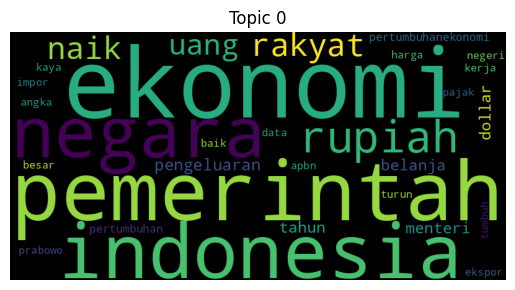

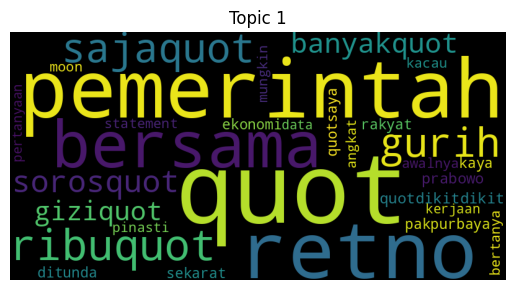

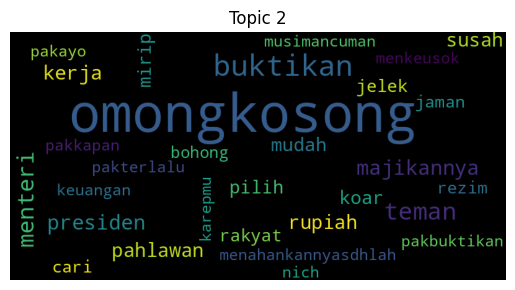

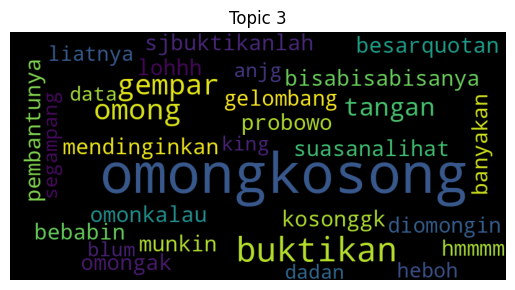

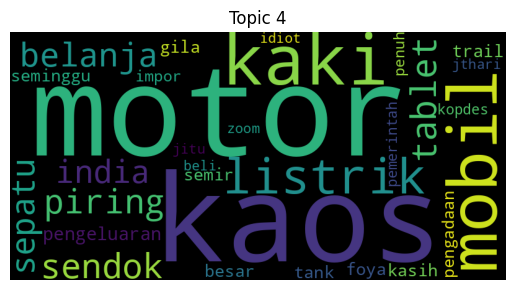

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for topic_id in topic_model.get_topics():
    if topic_id == -1:
        continue

    words = dict(topic_model.get_topic(topic_id))
    wc = WordCloud(width=800, height=400).generate_from_frequencies(words)

    plt.figure()
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Topic {topic_id}")
    plt.show()

# **TOPIC MODELLING ABC OPTIMIZER**

In [ ]:
from bertopic.representation import MaximalMarginalRelevance

mmr = MaximalMarginalRelevance(diversity=0.3)

topic_model_2 = BERTopic(
    umap_model=best_model.umap_model,
    hdbscan_model=best_model.hdbscan_model,
    vectorizer_model=best_model.vectorizer_model,
    representation_model=mmr,
    verbose=True
)

topics, probs = topic_model_2.fit_transform(docs, embeddings)

2026-05-13 12:27:46,813 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-13 12:28:18,390 - BERTopic - Dimensionality - Completed ✓
2026-05-13 12:28:18,393 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-13 12:28:18,817 - BERTopic - Cluster - Completed ✓
2026-05-13 12:28:18,828 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-13 12:28:19,027 - BERTopic - Representation - Completed ✓


In [ ]:
print("Shape embeddings sebelum UMAP:")
print(embeddings.shape)
reduced_embeddings = best_model.umap_model.transform(embeddings)

print("\nShape embeddings setelah UMAP:")
print(reduced_embeddings.shape)

Shape embeddings sebelum UMAP:
(4721, 768)

Shape embeddings setelah UMAP:
(4721, 5)


## Summary Topic

In [ ]:
topic_info = topic_model_2.get_topic_info()
print(topic_info)

   Topic  Count                                   Name  \
0     -1    186       -1_naik_indonesia_buzzer_optimis   
1      0   4383  0_ekonomi_pemerintah_indonesia_negara   
2      1     73                 1_koma_enam_puluh_quot   
3      2     45   2_omongkosong_buktikan_teman_menteri   
4      3     34    3_omongkosong_buktikan_omong_gempar   

                                      Representation  \
0  [naik, indonesia, buzzer, optimis, ekonomi, pe...   
1  [ekonomi, pemerintah, indonesia, negara, rupia...   
2  [koma, enam, puluh, quot, belakang, pemerintah...   
3  [omongkosong, buktikan, teman, menteri, presid...   
4  [omongkosong, buktikan, omong, gempar, merahpu...   

                                 Representative_Docs  
0  [optimis percaya ekonomi pemerintah solid komp...  
1  [belanja pemerintah besar impor efek perekonom...  
2  [nyebut angka belakang koma disebut enam enam ...  
3  [omong_kosong omong_kosong buktikan, cium kaki...  
4  [bebabin omong_kosong bisanya nyinyi

## Proporsi Topik

In [ ]:
topic_counts = topic_info[["Topic","Count"]]
topic_counts["Percentage"] = topic_counts["Count"] / topic_counts["Count"].sum()
print(topic_counts)

   Topic  Count  Percentage
0     -1    186    0.039398
1      0   4383    0.928405
2      1     73    0.015463
3      2     45    0.009532
4      3     34    0.007202


## Keyword per Topic (MMR + TF-IDF)

In [ ]:
for topic_id in topic_model_2.get_topics():
    if topic_id == -1:
        continue
    print(f"\nTopic {topic_id}:")
    print(topic_model_2.get_topic(topic_id))


Topic 0:
[('ekonomi', np.float64(0.03854016593263823)), ('pemerintah', np.float64(0.03666748353727748)), ('indonesia', np.float64(0.033984748753604)), ('negara', np.float64(0.0335587575125273)), ('rupiah', np.float64(0.02971993225505871)), ('rakyat', np.float64(0.028623752882781937)), ('naik', np.float64(0.02805168523210052)), ('uang', np.float64(0.0245112127196552)), ('pengeluaran', np.float64(0.019787782660584976)), ('belanja', np.float64(0.01885646279309012)), ('dollar', np.float64(0.01779757690867013)), ('pertumbuhanekonomi', np.float64(0.017496985720072963)), ('menteri', np.float64(0.017460877710578287)), ('tahun', np.float64(0.01743790983266843)), ('pertumbuhan', np.float64(0.016952993569420753)), ('harga', np.float64(0.015692531924805516)), ('besar', np.float64(0.015101159231463913)), ('data', np.float64(0.014150626672813731)), ('tumbuh', np.float64(0.014062572089650276)), ('baik', np.float64(0.013983992651081228)), ('apbn', np.float64(0.013904394768723797)), ('kaya', np.float6

## Outlier

In [ ]:
outlier_pct = (topic_info.loc[topic_info["Topic"] == -1, "Count"].values[0]) / len(docs)
print("Outlier %:", outlier_pct)

Outlier %: 0.03939843253547977


# **VISUALISASI**

## UMAP Plot

In [ ]:
from umap import UMAP
reduced_embeddings = UMAP(n_neighbors=23, n_components=5, min_dist=0.0, metric='cosine').fit_transform(embeddings)
topic_model_2.visualize_documents(docs, reduced_embeddings=reduced_embeddings)

## Topic Distribution

In [ ]:
topic_model_2.visualize_barchart()

## Wordcloud

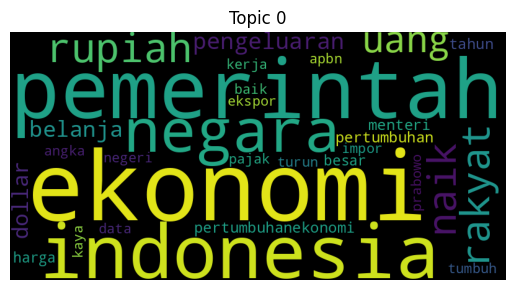

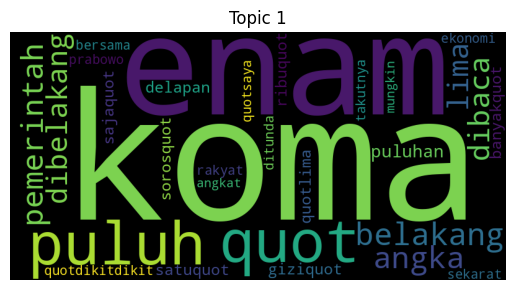

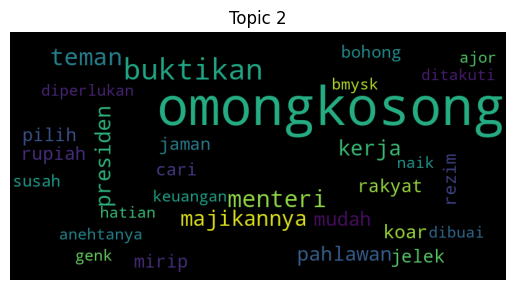

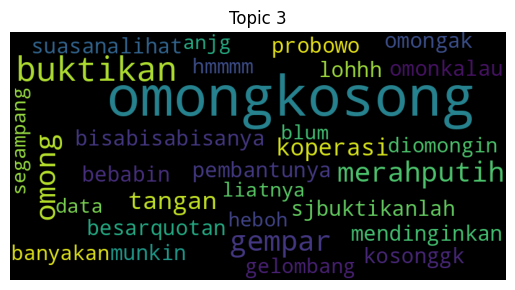

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for topic_id in topic_model_2.get_topics():
    if topic_id == -1:
        continue

    words = dict(topic_model_2.get_topic(topic_id))
    wc = WordCloud(width=800, height=400).generate_from_frequencies(words)

    plt.figure()
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Topic {topic_id}")
    plt.show()